---
title: "Practice Activity 2-2"
format:
  html:
    embed-resources: true
---

# Wrangling and Summarizing Data

Read this notebook from top to bottom and fill in the code as you go. Work together and discuss with other students in the class. Try to resolve any errors on your own first, but don't get stuck; ask for help!

In addition to writing and running code, be sure to examine any output and interpret the results before moving on.

For many of these questions, there are several ways to do it in Pandas. You only need to choose one that works. But you might want to experiment with multiple ways of doing the same thing to get practice working with Pandas. However, you should generally try to find the simplest solution. In particular, use `groupby` whenever possible to streamline the code.

In [1]:
import pandas as pd

## Titanic data

In [2]:
df_titanic = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/main/data/titanic.csv")
df_titanic

,name,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2202,"Wynn, Mr. Walter",male,41.0,deck crew,B,England,NaN,NaN,1,NaN,deck crew
2203,"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,NaN,NaN,1,NaN,victualling crew
2204,"Young, Mr. Francis James",male,32.0,engineering crew,S,England,NaN,NaN,0,NaN,engineering crew
2205,"Zanetti, Sig. Minio",male,20.0,restaurant staff,S,England,NaN,NaN,0,NaN,restaurant staff


1\. Create a new variable "type" that takes values either "passenger" or "crew".

In [5]:
def re_class_for_type_var(c):
    if c in ['1st', '2nd', '3rd']:
        return 'passenger'
    else:
        return 'crew'

df_titanic["type"] = df_titanic["class"].map(re_class_for_type_var)
df_titanic

,name,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew,type
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN,passenger
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN,passenger
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN,passenger
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN,passenger
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN,passenger
...,...,...,...,...,...,...,...,...,...,...,...,...
2202,"Wynn, Mr. Walter",male,41.0,deck crew,B,England,NaN,NaN,1,NaN,deck crew,crew
2203,"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,NaN,NaN,1,NaN,victualling crew,crew
2204,"Young, Mr. Francis James",male,32.0,engineering crew,S,England,NaN,NaN,0,NaN,engineering crew,crew
2205,"Zanetti, Sig. Minio",male,20.0,restaurant staff,S,England,NaN,NaN,0,NaN,restaurant staff,crew


In [6]:
pd.crosstab(df_titanic["class"],df_titanic["type"])

type,crew,passenger
class,,
1st,0,324
2nd,0,284
3rd,0,709
deck crew,66,0
engineering crew,324,0
restaurant staff,69,0
victualling crew,431,0


2\. Find the proportion those onboard who were passengers and the proportion who were crew. Do this by creating a Series with these proportions.

In [8]:
df_titanic["type"].value_counts(normalize=True)

type
passenger    0.596738
crew         0.403262
Name: proportion, dtype: float64

3\. Note that "survived" is a categorical variable that has been one-hot encoded as a dummy (aka Bernoulli aka indicator) numerical variable with 1 = survived and 0 = not survived. (Check its dtype.) Find the proportion of those onboard who survived. You could do this with `value_counts` like for "type", but try a different way that takes advantage of the fact that "survived" is a numerical type. (Hint: what happens if you sum the values of a 1/0 variable? What happens if you take the mean of the values of a 1/0 variable?)

In [16]:
from dask.array import mean
df_titanic["survived"].value_counts(normalize=True)


survived
0    0.677843
1    0.322157
Name: proportion, dtype: float64

In [17]:
df_titanic["survived"].mean()

np.float64(0.3221567739012234)

4\. Create a crosstab (two-way table) summarizing the joint distribution of "survived" and "type". (Notice that we can treat the dummy variable "survived" as both a categorical variable and a numerical variable, whichever is convenient.)

In [12]:
pd.crosstab(df_titanic["survived"],df_titanic["type"])

type,crew,passenger
survived,,
0,679,817
1,211,500


5\. Compare the proportion of passengers who survived and the proportion of crew members who survived. Do this by creating a Series that contains these two proportions. Who was more likely to survive: passengers or crew?

Hint: there are a few ways of doing this, several of which avoid explicitly dividing. Can you take advantage of `groupby` and the fact that "survived" is a dummy variable?

In [23]:
df_titanic.groupby("type")["survived"].mean()

type
crew         0.237079
passenger    0.379651
Name: survived, dtype: float64

In [27]:
pd.crosstab(df_titanic["type"],df_titanic["survived"], normalize= "index")

survived,0,1
type,,
crew,0.762921,0.237079
passenger,0.620349,0.379651


6\. The "gender" variable is coded only as "male" or "female". Among males only, compare the proportion of passengers who survived and the proportion of cew who survived. Among males, who was more likely to survive: passengers or crew? Then do the same thing among females only. Among females, who was more likely to survive: passengers or crew?

Do this by creating a Series that contains the 4 proportions you need. Hint: if you used `groupby` in the previous part you should only need a small change here.

In [36]:
df_titanic.groupby(["gender", "type"])["survived"].mean()

gender  type     
female  crew         0.869565
        passenger    0.727468
male    crew         0.220300
        passenger    0.189189
Name: survived, dtype: float64

7\. Compare your answers to 5 and 6. What do you notice? Can you explain why this happens? Suggest an explanation and then create summaries of the data to support your explanation.

The proportion of female crew members and female passengers that survived was much higher than those of males who survived likely because more females survived the Titanic than males.

In [40]:
df_titanic.groupby(["gender"])["survived"].mean()

gender
female    0.734151
male      0.204889
Name: survived, dtype: float64

In [38]:
df_titanic.groupby(["gender"])["type"].value_counts(normalize=True)

gender  type     
female  passenger    0.952965
        crew         0.047035
male    crew         0.504657
        passenger    0.495343
Name: proportion, dtype: float64

## College Scorecard

The [College Scorecard](https://collegescorecard.ed.gov/) was an effort started by the U.S. Department of Education to help students make more informed choices about colleges. Data from 2022 is available at https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv


In [42]:
df_college = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv")

df_college

,Institution,City,State,Undergraduates,Median Earnings
0,Alabama A & M University,Normal,AL,5098.0,39059.0
1,University of Alabama at Birmingham,Birmingham,AL,13284.0,50907.0
2,Amridge University,Montgomery,AL,251.0,37730.0
3,University of Alabama in Huntsville,Huntsville,AL,7358.0,56901.0
4,Alabama State University,Montgomery,AL,3495.0,34018.0
...,...,...,...,...,...
6538,Pennsylvania State University-Penn State York,York,PA,NaN,61185.0
6539,Pennsylvania State University-Penn State Great...,Malvern,PA,NaN,61185.0
6540,Pennsylvania State University-Penn State Harri...,Middletown,PA,NaN,61185.0
6541,Pennsylvania State University-Penn State Brand...,Media,PA,NaN,61185.0


1\. What is the observational unit? Make a guess for how the earnings variable is computed.

**The observational units are the different institutions.**

2\. Write code to find the California Polytechnic row in the data set!

In [48]:
df_college[df_college["Institution"].str.contains("California Polytechnic")]

,Institution,City,State,Undergraduates,Median Earnings
194,California Polytechnic State University-San Lu...,San Luis Obispo,CA,21090.0,85801.0


3\. The data set contains information about the median earnings of students who attended each college, 10 years after they first enrolled. The earnings are taken directly from the W2 tax forms of all students who received federal financial aid.

Notice the earnings are missing (NaN). Create a subset data frame that only includes colleges with non-missing earnings. Use this subset to answer the remaining questions.

In [55]:
college_subset = df_college.dropna(subset = ["Median Earnings"])

In [52]:
college_subset[:300]

,Institution,City,State,Undergraduates,Median Earnings
0,Alabama A & M University,Normal,AL,5098.0,39059.0
1,University of Alabama at Birmingham,Birmingham,AL,13284.0,50907.0
2,Amridge University,Montgomery,AL,251.0,37730.0
3,University of Alabama in Huntsville,Huntsville,AL,7358.0,56901.0
4,Alabama State University,Montgomery,AL,3495.0,34018.0
...,...,...,...,...,...
329,Southern California University of Health Sciences,Whittier,CA,130.0,63949.0
330,Los Angeles Harbor College,Wilmington,CA,5487.0,39602.0
331,Los Angeles Pierce College,Woodland Hills,CA,13016.0,43074.0
332,Los Angeles Southwest College,Los Angeles,CA,3539.0,29508.0


4\. Summarize the earnings variable, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command! What is larger: the mean or the median? Why? Then create a histogram of the earnings variable.

In [57]:
college_subset["Median Earnings"].describe()

count      5165.000000
mean      41128.801355
std       16185.531482
min       11085.000000
25%       29448.000000
50%       38696.000000
75%       49077.000000
max      129442.000000
Name: Median Earnings, dtype: float64

<Axes: ylabel='Frequency'>

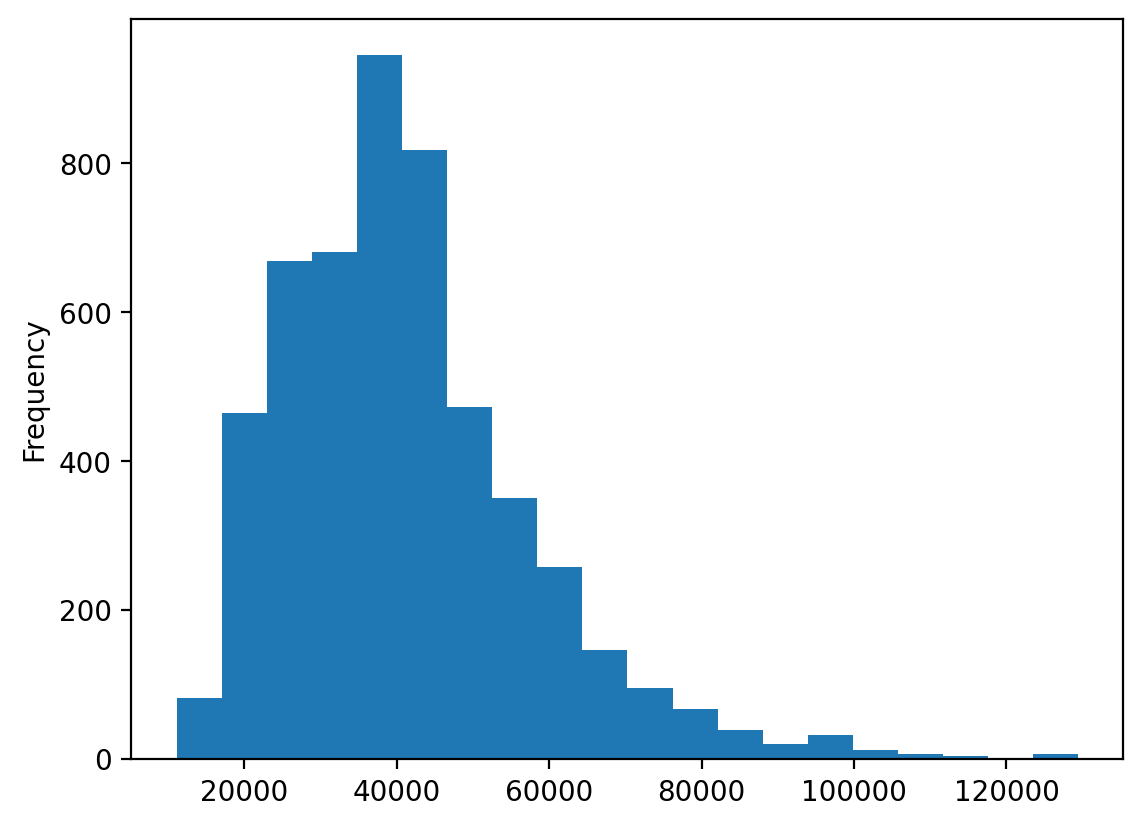

In [59]:
college_subset["Median Earnings"].plot.hist(bins=20)

5\. Create a new column with the log of earnings, then create a histogram. How does the shape of the histogram of log earnings compare to earnings itself?

In [64]:
import numpy as np
college_subset["log Median Earnings"] = np.log(college_subset["Median Earnings"])

<Axes: ylabel='Frequency'>

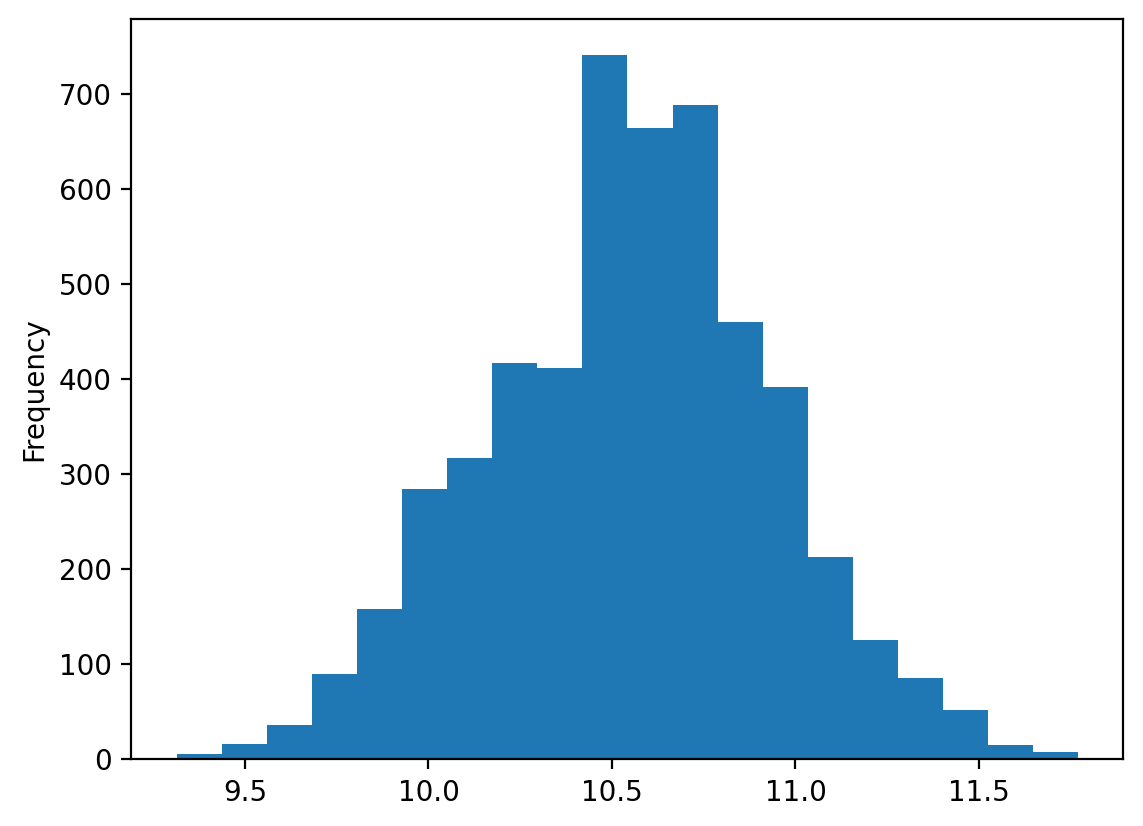

In [68]:
college_subset["log Median Earnings"].plot.hist(bins=20)

6\. The mean gives every college equal weight. But some colleges are tiny (e.g., San Francisco Conservatory, with 228 undergraduates), while others are large (e.g., Penn State, with 72229 undergraduates!).

If we are interested in what *students* earn, we might want to give more weight to colleges with more students. To do this, we can calculate a **weighted mean**:

$$ \sum_{i=1}^n w_i x_i. $$

In general, the weights $w_1, w_2, ..., w_n$ should all be non-negative and should add up to $1.0$. (For the usual mean, every observation gets equal weight, $1/n$.)

Calculate a weighted mean of earnings, using the undergraduate enrollments as weights. Do this by first adding a "weight" column to the data set (number of undegraduates for the college divided by the total number of undergraduates in the data set).

In [69]:
college_subset["weight"] = college_subset["Undergraduates"] / college_subset["Undergraduates"].sum()


In [70]:
(college_subset["weight"] * college_subset["Median Earnings"]).sum()

np.float64(50608.33831282287)

7\. Compute the mean of earnings for each state. Sort the states in descending order of mean earnings. Display the results in a bar chart.

In [72]:
college_subset.groupby("State")["Median Earnings"].mean()

State
AK    43604.500000
AL    38225.338028
AR    32972.202703
AS    28524.000000
AZ    40854.298851
CA    44461.812371
CO    41578.523077
CT    50771.413793
DC    51325.470588
DE    40319.153846
FL    36162.099668
FM    23377.000000
GA    38845.460526
GU    31082.000000
HI    42162.437500
IA    41809.521127
ID    32823.666667
IL    42443.338624
IN    43311.268519
KS    41244.690141
KY    35171.828571
LA    34087.642857
MA    56633.768519
MD    44454.342857
ME    43400.032258
MH    34483.000000
MI    37855.232394
MN    45855.938776
MO    41702.425197
MP    25107.000000
MS    31897.104167
MT    37653.480000
NC    37178.948387
ND    39603.080000
NE    43776.868421
NH    49322.333333
NJ    44964.081081
NM    36994.588235
NV    41184.741935
NY    48752.694352
OH    40115.951613
OK    35564.678161
OR    41934.816667
PA    47607.290210
PR    22257.669173
PW    31212.000000
RI    52605.947368
SC    36446.682927
SD    41136.608696
TN    36866.411290
TX    38074.490683
UT    35862.604651
VA    

8\. Repeat the previous part, but now compute a weighted mean of earnings for each state, using the number of undegraduate enrollments in the state as weights. (Hint: use `groupby` with `transform`.)

In [74]:
college_subset["state_weight"] = college_subset["Undergraduates"] / college_subset.groupby("State")["Undergraduates"].transform("sum")

college_subset["weighted_earnings"] = college_subset["state_weight"] * college_subset["Median Earnings"]

college_subset.groupby("State")["weighted_earnings"].sum()

State
AK    47484.939237
AL    46235.575067
AR    42616.774237
AS    28524.000000
AZ    46269.729336
CA    51861.217937
CO    50724.480712
CT    58515.071887
DC    69939.367698
DE    56136.291687
FL    46868.957171
FM    23377.000000
GA    47246.144980
GU    32092.752281
HI    48235.746445
IA    51723.723529
ID    48550.410338
IL    52567.618773
IN    50227.922229
KS    47195.607294
KY    42942.305706
LA    43624.414206
MA    65365.038613
MD    56049.152616
ME    47025.392744
MH    34483.000000
MI    50057.879324
MN    53257.575881
MO    49111.791894
MP    25107.000000
MS    38593.953921
MT    46245.688158
NC    45554.928093
ND    53733.319895
NE    51268.810074
NH    55043.032070
NJ    54956.421801
NM    38089.932224
NV    46974.859922
NY    57869.188381
OH    46457.828084
OK    45200.927650
OR    50632.035920
PA    58152.366783
PR    26105.497420
PW    31212.000000
RI    61382.901051
SC    46361.251566
SD    47463.984742
TN    44455.268088
TX    48719.078342
UT    54274.369021
VA    

## Olympic Men's Gymnastics Data



The file https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv contains scores from the qualification and final rounds of the Olympic men's gymnastics all around competition from 2008 to 2020. (Thanks to Martin Hsu for scraping this data set.)

In [101]:
df_gym = pd.read_csv("https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv")

df_gym

,Pos,Gymnast,NOC,Points,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse,Round,Year
0,1.0,Danell Leyva,USA,91.265,15.100,15.500,15.333,15.866,14.600,14.866,Qualification,2012
1,2.0,David Belyavsky,RUS,90.832,15.100,16.300,15.300,14.866,14.366,14.900,Qualification,2012
2,3.0,Fabian HambÃ¼chen,GER,90.765,15.133,15.833,15.300,15.633,14.766,14.100,Qualification,2012
3,4.0,John Orozco,USA,90.597,15.166,15.800,14.533,15.266,15.066,14.766,Qualification,2012
4,5.0,Kristian Thomas,GBR,90.256,15.366,16.200,14.625,15.366,14.566,14.133,Qualification,2012
...,...,...,...,...,...,...,...,...,...,...,...,...
346,20.0,Daniel Keatings,GBR,89.000,14.850,15.800,14.425,14.225,14.000,15.700,Final,2008
347,21.0,Thomas Bouhail,FRA,87.000,15.200,15.850,14.425,14.475,13.650,13.400,Final,2008
348,22.0,José Luis Fuentes,VEN,86.300,14.175,15.250,15.175,14.150,13.900,13.650,Final,2008
349,23.0,Dzmitry Savitski,BLR,82.175,13.725,15.900,13.400,10.100,15.300,13.750,Final,2008


1\. Create a data frame

- With [Round, Year, Gymnast] as the (multi) index, and
- Containing only the six columns with the event scores, "Floor Exercise" through "Pommelled Horse"

In [104]:
df_gym2 = df_gym.set_index(["Round", "Year", "Gymnast"])[[
    "Floor Exercise",
    "Horse Vault",
    "Parallel Bars",
    "Horizontal Bar",
    "Rings",
    "Pommelled Horse"
]]

df_gym2

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva               15.100       15.500   
                   David Belyavsky            15.100       16.300   
                   Fabian HambÃ¼chen          15.133       15.833   
                   John Orozco                15.166       15.800   
                   Kristian Thomas            15.366       16.200   
...                                              ...          ...   
Final         2008 Daniel Keatings            14.850       15.800   
                   Thomas Bouhail             15.200       15.850   
                   José Luis Fuentes          14.175       15.250   
                   Dzmitry Savitski           13.725       15.900   
                   Chen Yibing                   NaN       15.900   

                                      Parallel Bars  Horizontal Bar   Rings  \
Round         Year Gymnast                                                    
Qualification 2012 Danell Leyva              15.333          15.866  14.600   
                   David Belyavsky           15.300          14.866  14.366   
                   Fabian HambÃ¼chen         15.300          15.633  14.766   
                   John Orozco               14.533          15.266  15.066   
                   Kristian Thomas           14.625          15.366  14.566   
...                                             ...             ...     ...   
Final         2008 Daniel Keatings           14.425          14.225  14.000   
                   Thomas Bouhail            14.425          14.475  13.650   
                   José Luis Fuentes         15.175          14.150  13.900   
                   Dzmitry Savitski          13.400          10.100  15.300   
                   Chen Yibing               14.950          12.975  16.650   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva                14.866  
                   David Belyavsky             14.900  
                   Fabian HambÃ¼chen           14.100  
                   John Orozco                 14.766  
                   Kristian Thomas             14.133  
...                                               ...  
Final         2008 Daniel Keatings             15.700  
                   Thomas Bouhail              13.400  
                   José Luis Fuentes           13.650  
                   Dzmitry Savitski            13.750  
                   Chen Yibing                 13.750  

[351 rows x 6 columns]

2\. Summarize the scores for each of the six events, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command!

In [105]:
df_gym2.describe()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
count,324.000000,323.000000,323.000000,324.000000,318.000000,325.000000
mean,14.309133,14.976551,14.719288,14.082562,14.237799,13.816723
std,1.254009,0.959876,0.920044,1.299542,0.914523,1.242348
min,1.633000,11.766000,10.200000,0.000000,7.700000,0.000000
25%,13.866000,14.300000,14.233000,13.475000,13.700000,13.266000
50%,14.500000,15.058000,14.900000,14.300000,14.275000,13.925000
75%,15.033000,15.700000,15.350000,14.854000,14.831000,14.566000
max,15.950000,16.775000,16.425000,16.200000,16.650000,16.000000


3\. There are 351 rows in the data frame. Why are the sample sizes different for each event, and not all equal to 351?

**This is most likely because there are missing values for some of the events.**

4\. In the all around competition, each gymnast competes all six events, but this doesn't always happen (due to injury, etc). Therefore, there are some missing values in the data. Most of the missing values are coded as `NaN` but some are coded as 0. What would be a more appropriate way to code the missing values in this case: `NaN` or 0? Why?

**It would be more appropriate to code them as NaN because a 0 would be considered a low score, which would bring down their averages. ****

5\. Replace all scores of 0 in the data frame with `NaN`. (Note: It is possible to actually score a 0 on some events, e.g., if you do a vault but don't land feet first. But the few 0s in this data set are for people who didn't compete the event at all.)

In [106]:
df_gym3 = df_gym2.replace(0, np.nan)

6\. Summarize the revised data. Which events tend to have the highest scores? The lowest? Which events have the greatest degree of variability in scores? The least?

In [107]:
df_gym3.describe()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
count,324.000000,323.000000,323.000000,323.000000,318.000000,324.000000
mean,14.309133,14.976551,14.719288,14.126161,14.237799,13.859367
std,1.254009,0.959876,0.920044,1.037426,0.914523,0.977423
min,1.633000,11.766000,10.200000,9.433000,7.700000,10.666000
25%,13.866000,14.300000,14.233000,13.475000,13.700000,13.266000
50%,14.500000,15.058000,14.900000,14.300000,14.275000,13.925000
75%,15.033000,15.700000,15.350000,14.858000,14.831000,14.574500
max,15.950000,16.775000,16.425000,16.200000,16.650000,16.000000


Horse vault has highest avg and Pommeled horse has lowest avg. Floor exercise has highest variability and Rings has the lowest variability.

7\. Compute the correlation matrix. For which pairs of events is the correlation the highest? The lowest?

In [108]:
df_gym3.corr()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
Floor Exercise,1.000000,0.440092,0.351537,0.378685,0.494417,0.289385
Horse Vault,0.440092,1.000000,0.383301,0.500211,0.595005,0.367616
Parallel Bars,0.351537,0.383301,1.000000,0.557611,0.589963,0.481337
Horizontal Bar,0.378685,0.500211,0.557611,1.000000,0.491114,0.449014
Rings,0.494417,0.595005,0.589963,0.491114,1.000000,0.420985
Pommelled Horse,0.289385,0.367616,0.481337,0.449014,0.420985,1.000000


The highest correlation is horse vault and rings, and the lowest correlation is floor exercises and pommlled horse

8\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.

In [110]:
df_gym4 = (df_gym3 - df_gym3.mean()) / df_gym3.std()
df_gym4

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva             0.630671     0.545330   
                   David Belyavsky          0.630671     1.378771   
                   Fabian HambÃ¼chen        0.656987     0.892250   
                   John Orozco              0.683303     0.857870   
                   Kristian Thomas          0.842791     1.274591   
...                                              ...          ...   
Final         2008 Daniel Keatings          0.431311     0.857870   
                   Thomas Bouhail           0.710416     0.909960   
                   José Luis Fuentes       -0.106963     0.284879   
                   Dzmitry Savitski        -0.465812     0.962050   
                   Chen Yibing                   NaN     0.962050   

                                      Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                      
Qualification 2012 Danell Leyva            0.667047        1.677073  0.396055   
                   David Belyavsky         0.631179        0.713149  0.140184   
                   Fabian HambÃ¼chen       0.631179        1.452479  0.577570   
                   John Orozco            -0.202477        1.098718  0.905610   
                   Kristian Thomas        -0.102482        1.195111  0.358877   
...                                             ...             ...       ...   
Final         2008 Daniel Keatings        -0.319863        0.095273 -0.260025   
                   Thomas Bouhail         -0.319863        0.336254 -0.642738   
                   José Luis Fuentes       0.495316        0.022979 -0.369372   
                   Dzmitry Savitski       -1.433940       -3.880914  1.161481   
                   Chen Yibing             0.250762       -1.109632  2.637661   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva              1.029884  
                   David Belyavsky           1.064669  
                   Fabian HambÃ¼chen         0.246191  
                   John Orozco               0.927574  
                   Kristian Thomas           0.279953  
...                                               ...  
Final         2008 Daniel Keatings           1.883148  
                   Thomas Bouhail           -0.469978  
                   José Luis Fuentes        -0.214203  
                   Dzmitry Savitski         -0.111893  
                   Chen Yibing              -0.111893  

[351 rows x 6 columns]

9\. The all around champion is whoever has the highest total score for the six events (in the finals). But who is the "all around standardized value champion"? Create a column that sums the standardized values for each athlete, then sort the data frame in descending order by that column. Note: you should NOT have to manually add six columns.

In [111]:
df_gym4["Standardized Total"] = df_gym4.sum(axis=1)

df_gym4.sort_values("Standardized Total", ascending=False)

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                         
Final         2008 Yang Wei                0.750288     1.639221   
Qualification 2008 Yang Wei                0.869904     1.639221   
Final         2012 Kohei Uchimura          0.630671     1.343350   
Qualification 2008 Kim Dae-Eun             0.949648     1.118320   
                   Li Xiaopeng             0.630671     1.873626   
...                                             ...          ...   
              2020 Uche Eke               -1.177131    -1.608074   
                   David Huddleston       -1.496108    -1.017372   
                   Hung Yuan-Hsi          -0.858154    -2.094595   
                   David Rumbutis         -1.709025    -1.954993   
                   Jeremiah Loo           -0.964214    -2.615495   

                                     Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                     
Final         2008 Yang Wei               1.500703        0.625432  2.610324   
Qualification 2008 Yang Wei               0.685524        0.770020  2.172938   
Final         2012 Kohei Uchimura         0.658351        1.420669  1.197566   
Qualification 2008 Kim Dae-Eun            1.446357        0.480843  1.325501   
                   Li Xiaopeng            1.853947        1.227884  0.614748   
...                                            ...             ...       ...   
              2020 Uche Eke              -2.702358       -2.531420 -2.556304   
                   David Huddleston      -1.688276       -2.564194 -2.228264   
                   Hung Yuan-Hsi         -3.499060       -1.085534 -1.754793   
                   David Rumbutis        -3.245811       -1.535687 -3.321730   
                   Jeremiah Loo          -4.912036       -2.275016 -7.148862   

                                     Pommelled Horse  Standardized Total  
Round         Year Gymnast                                                
Final         2008 Yang Wei                 1.448331            8.574298  
Qualification 2008 Yang Wei                 1.601796            7.739403  
Final         2012 Kohei Uchimura           1.234504            6.485111  
Qualification 2008 Kim Dae-Eun              0.885627            6.206298  
                   Li Xiaopeng                   NaN            6.200877  
...                                              ...                 ...  
              2020 Uche Eke                -1.016312          -11.591600  
                   David Huddleston        -2.925414          -11.919628  
                   Hung Yuan-Hsi           -3.164819          -12.456954  
                   David Rumbutis          -1.868553          -13.635800  
                   Jeremiah Loo            -1.630171          -19.545795  

[351 rows x 7 columns]

10\. Compute the mean score for each event in each year. How do the means change over time? Why do you think this happened?

In [113]:
df_gym2.groupby("Year").mean()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
Year,,,,,,
2008,14.720250,15.841753,15.125758,14.563750,14.850532,14.248750
2012,14.495154,15.484308,14.663231,14.144908,14.441462,13.575062
2016,14.134667,14.496068,14.787083,14.246315,14.201514,14.051319
2020,13.841989,14.046398,14.242529,13.336919,13.453632,13.312341


The means decrease over time, maybe because the judging is getting more intense.

11\. Choose one event and for that event create a plot with a single panel that summarizes the distribution of scores for each of the four years. Describe what you see.

In [118]:
df_gym["Year"] = df_gym["Year"].astype(str)

In [120]:
import pandas as pd
from plotnine import ggplot, geom_point, aes, geom_boxplot, geom_histogram
     

/opt/anaconda3/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 27 rows containing non-finite values.


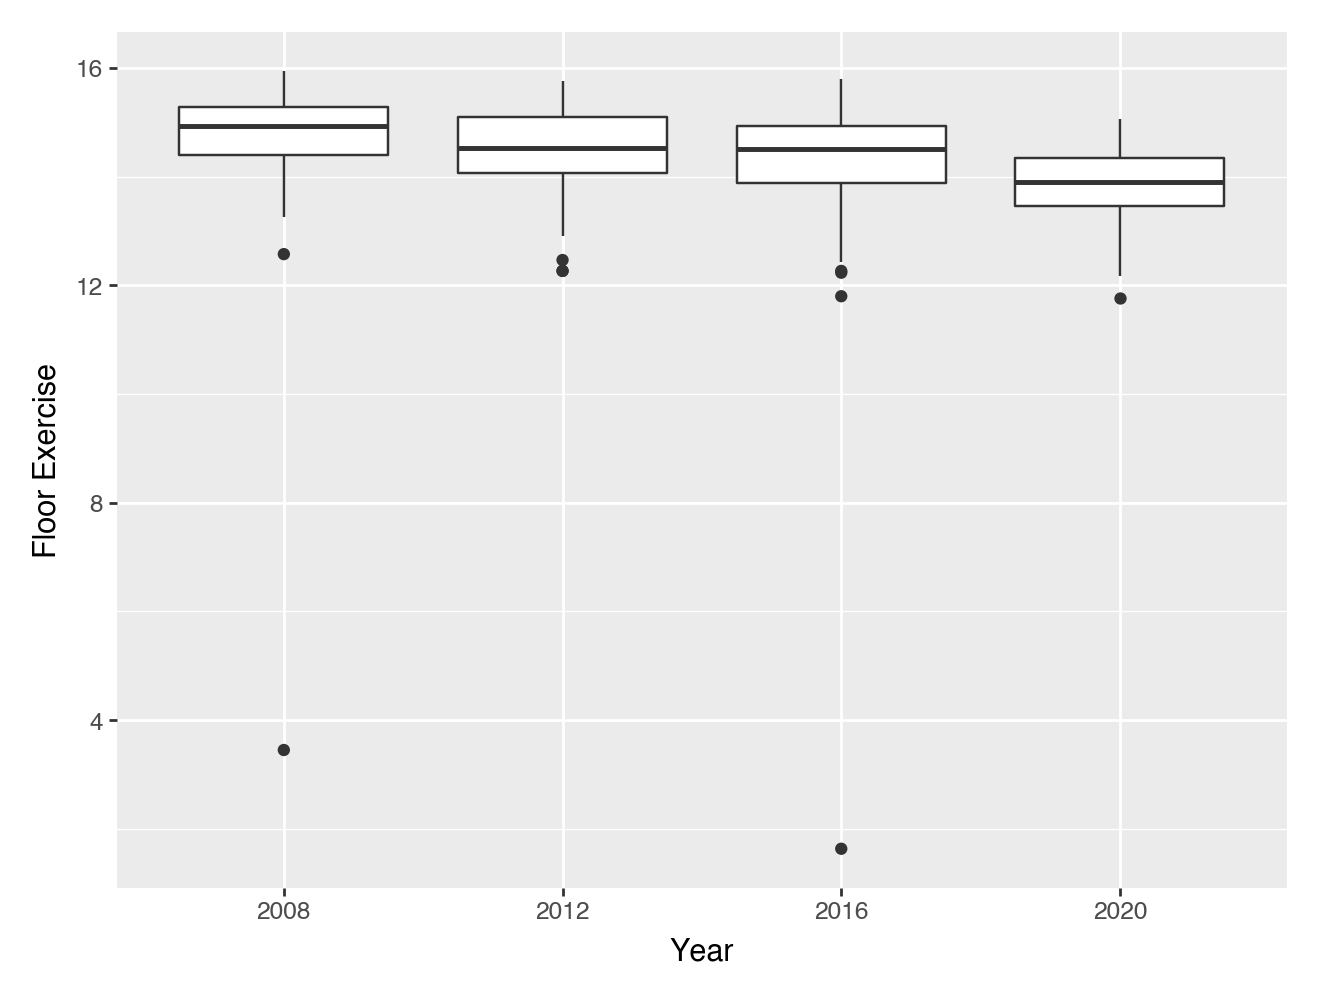

In [121]:
(ggplot(df_gym,
       aes(x="Year", y="Floor Exercise"))
 + geom_boxplot()
)

12\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation *within each year*. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.


In [122]:
events = [
    "Floor Exercise",
    "Horse Vault",
    "Parallel Bars",
    "Horizontal Bar",
    "Rings",
    "Pommelled Horse"
]

In [124]:
df_gym5 = (df_gym[events] - df_gym.groupby("Year")[events].transform("mean")) / df_gym.groupby("Year")[events].transform("std")

13\. If we standardize within each year, which athletes (and rounds and year) had the highest total standardized values? Basically repeat part 9 but with standardization within each year.

In [127]:
df_gym5[["Round", "Year", "Gymnast"]] = df_gym[["Round", "Year", "Gymnast"]]

df_gym5.sort_values("Standardized Total", ascending=False)

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse,Standardized Total,Round,Year,Gymnast
116,0.520383,1.475149,1.524323,0.534169,2.005141,1.554973,7.614139,Final,2016,Oleh Verniaiev
139,1.196662,1.341947,1.007048,1.915265,0.443776,1.488590,7.393287,Qualification,2020,Daiki Hashimoto
205,1.382156,1.070152,1.007048,1.802342,0.085413,1.898201,7.245313,Final,2020,Daiki Hashimoto
65,0.404528,0.837441,1.600950,0.855432,1.822604,1.589606,7.110561,Qualification,2016,Oleh Verniaiev
115,0.944993,1.572128,0.943813,1.498922,0.970158,0.890661,6.820674,Final,2016,Kohei Uchimura
...,...,...,...,...,...,...,...,...,...,...
199,-2.337488,-1.549551,-2.389868,-0.907808,-2.425281,-1.310083,-10.920078,Qualification,2020,David Rumbutis
113,-0.739543,-1.954366,-2.423146,-1.524613,-2.437804,-2.362683,-11.442155,Qualification,2016,KÃ©vin Crovetto
302,-8.587414,-1.274190,-0.288855,NaN,NaN,-2.133483,-12.283942,Qualification,2008,Brandon O'Neill
40,-0.450919,0.264513,-0.244442,-7.131465,2.247502,-7.078267,-12.393078,Qualification,2012,Matteo Morandi
